<h1 align='center'> 영상처리 프로그래밍 실습 1</h1>

<h6 align='right'> 2025. 3. 12.</h6>

<div class="alert alert-block alert-info">
    
- 파일 이름에서 00000000을 자신의 학번으로, name을 자신의 이름으로 수정하세요.

- 다음 줄에 자신의 이름, 학번, 학과(전공)을 적으세요.

* 이름:   이한석          학번:    20215226         학과(전공):   빅데이터학과
    
</div>

- JupyterLab 문서의 최신 버전은 [JupyterLab Documentation](https://jupyterlab.readthedocs.io/en/stable/index.html#/)을  참고하라

- Markdown은 [Markdown Guide](https://www.markdownguide.org/)를 참고하라.
- [Markdown Cheat Sheet](https://www.markdownguide.org/cheat-sheet/)

* 제출 마감: 3월 18일 (화) 오후 10:00까지 최종본 SmartLEAD제출


# 문제 1. Image file 이해하기

### Image file 읽기
주: 이 노트북 파일이 있는 디렉토리에 goldhill.bmp 파일이 있어야 한다.

In [ ]:
512*512*3 + 54  

786486

In [46]:
import imageio.v3 as iio
import matplotlib.pyplot as plt
import os
from matplotlib.widgets import Slider

In [ ]:
os.listdir('./') #현재 디렉터리의 모든 파일과 폴더 이름을 리스트

['goldhill.bmp', 'IPP_2025-01-lab-20215226-이한석.ipynb']

In [ ]:
img_file = 'goldhill.bmp' #이미지 파일
img = iio.imread(img_file) #이미지 읽어오기

In [ ]:
type(img) #넘파이

numpy.ndarray

In [12]:
img.shape, img.dtype  #(세로,가로,RGB) R 8비트 G 8비트 B 8비트

((512, 512, 3), dtype('uint8'))

In [ ]:
img #3차원 넘파이 배열

array([[[ 10,  10,  10],
        [230, 230, 230],
        [229, 229, 229],
        ...,
        [205, 205, 205],
        [200, 200, 200],
        [199, 199, 199]],

       [[202, 202, 202],
        [229, 229, 229],
        [227, 227, 227],
        ...,
        [201, 201, 201],
        [199, 199, 199],
        [200, 200, 200]],

       [[198, 198, 198],
        [231, 231, 231],
        [234, 234, 234],
        ...,
        [198, 198, 198],
        [199, 199, 199],
        [199, 199, 199]],

       ...,

       [[ 29,  29,  29],
        [103, 103, 103],
        [109, 109, 109],
        ...,
        [ 84,  84,  84],
        [ 72,  72,  72],
        [ 42,  42,  42]],

       [[ 28,  28,  28],
        [103, 103, 103],
        [116, 116, 116],
        ...,
        [ 88,  88,  88],
        [ 67,  67,  67],
        [ 39,  39,  39]],

       [[ 31,  31,  31],
        [114, 114, 114],
        [115, 115, 115],
        ...,
        [ 84,  84,  84],
        [ 73,  73,  73],
        [ 41,  41,  41]]

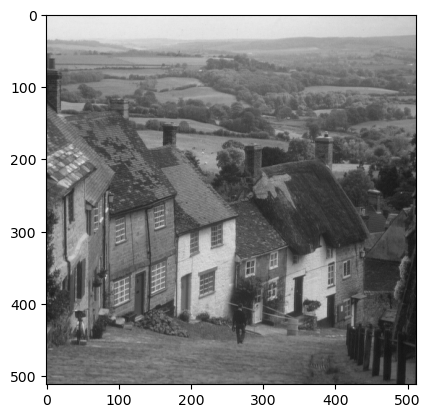

In [ ]:
plt.imshow(img) #이미지 출력

In [ ]:
img[0,0]+50 #브로드캐스팅

array([60, 60, 60], dtype=uint8)

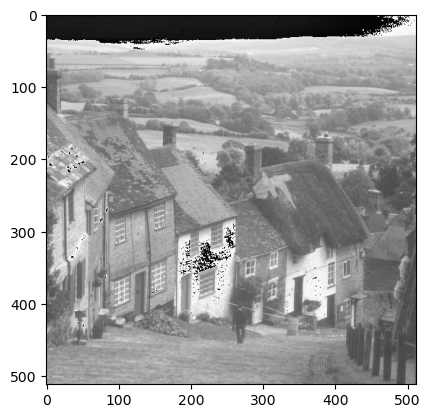

In [ ]:
plt.imshow(img+50) #이미지 밝기 증가, 검은색 부분 오버플로우

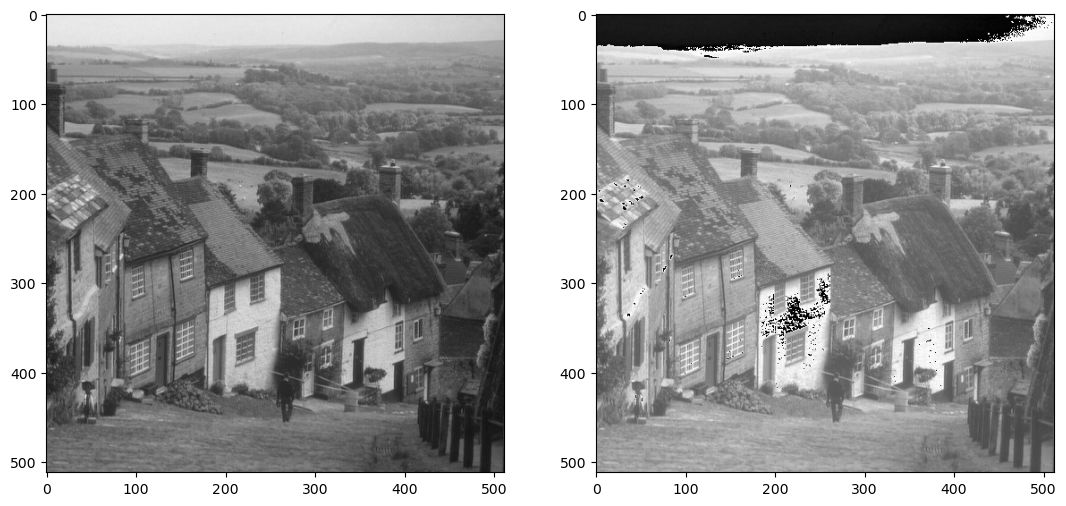

In [ ]:
plt.figure(figsize=[13,6]) #가로 13인치, 세로 6인치
plt.subplot(1,2,1) #세로 1개, 가로 2개, 첫번째
plt.imshow(img)
plt.subplot(1,2,2) #세로 1개, 가로 2개, 두번쨰
plt.imshow(img+50)  #검은색 오버플로우
plt.show() #이미지 화면에 출력

In [ ]:
print(img[0,:2,:])  #첫번째 깊이, 0~1 행, 모든 열
print(img[0,:2,:] + 50) #50 더하기

[[ 10  10  10]
 [230 230 230]]
[[60 60 60]
 [24 24 24]]


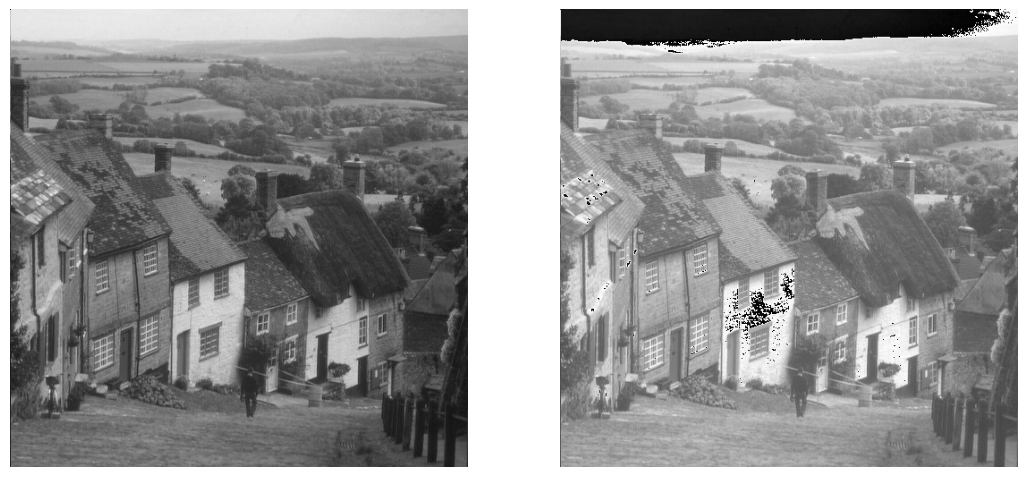

In [ ]:
plt.figure(figsize=[13,6])
plt.subplot(1,2,1) 
plt.imshow(img)
plt.axis('off') #축 끄기
plt.subplot(1,2,2)
plt.imshow(img+50)
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
img_mod = img.astype('float') #int->float
img[0,0], img_mod[0,0] 

(array([10, 10, 10], dtype=uint8), array([10., 10., 10.]))

In [ ]:
img_mod.dtype #float로 바뀜

dtype('float64')

In [ ]:
img_mod[0,1]+50 #50 더하기

array([280., 280., 280.])

In [ ]:
(img_mod+50).clip(0,255).astype(np.uint8) #클리핑 0보다 작은거 0, 255보다 큰거 255 / int로 다시 바꾸기

array([[[ 60,  60,  60],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [250, 250, 250],
        [249, 249, 249]],

       [[252, 252, 252],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [251, 251, 251],
        [249, 249, 249],
        [250, 250, 250]],

       [[248, 248, 248],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [248, 248, 248],
        [249, 249, 249],
        [249, 249, 249]],

       ...,

       [[ 79,  79,  79],
        [153, 153, 153],
        [159, 159, 159],
        ...,
        [134, 134, 134],
        [122, 122, 122],
        [ 92,  92,  92]],

       [[ 78,  78,  78],
        [153, 153, 153],
        [166, 166, 166],
        ...,
        [138, 138, 138],
        [117, 117, 117],
        [ 89,  89,  89]],

       [[ 81,  81,  81],
        [164, 164, 164],
        [165, 165, 165],
        ...,
        [134, 134, 134],
        [123, 123, 123],
        [ 91,  91,  91]]

In [13]:
%matplotlib qt 

In [ ]:
img_mod=(img.astype('float')+50).clip(0,255).astype(np.uint8) #오버플로우 발생x / float로 바꾸고 클리핑 후 int로 다시 바꾸기
plt.figure(figsize=[13,6])
plt.subplot(1,2,1) 
plt.imshow(img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(img_mod)
plt.axis('off')
plt.show()

In [ ]:
import imageio.v3 as iio
import matplotlib.pyplot as plt
import os
from matplotlib.widgets import Slider
import numpy as np

def update_add(val): #val 더한 이미지 출력
    global img_org, ax_mod
    img_ = np.clip(img_org +val,0,255)
    img_=img_.astype(np.uint8)
    ax_mod.set_data(img_)
    
def image_read(image_dir, image_file): #이미지 불러오기
    global img_org
    img_path = os.path.join(image_dir, image_file)
    img = iio.imread(img_path).astype(np.uint8)
    img_org=np.array(img).astype(np.uint8)
    return img_org

max_bias=200

img_dir='./'
img_file='goldhill.bmp'
image_read(img_dir,img_file) #이미지 읽기

plt.rc('font',size=20) #글꼴 크기 20
fig=plt.figure(figsize=[11.5,5.5]) #가로 11.5, 세로 5.5 figure 생성
ax_org_image=fig.add_subplot(1,2,1) #1행 2열 첫번째 위치
ax_mod_image=fig.add_subplot(1,2,2) #1행 2열 두번째 위치
ax_org=ax_org_image.imshow(img_org,cmap='gray',vmin=0,vmax=255) #흑백 이미지로 표시, 0~255
ax_mod=ax_mod_image.imshow(img_org,cmap='gray',vmin=0,vmax=255)

ax_org_image.axis('off') #축 숨기기
ax_mod_image.axis('off')


ax_slider=fig.add_axes([0.3,0.05,0.4,0.03],facecolor='w') #x위치,y위치,너비,높이
slider=Slider(ax_slider, 'bias', -max_bias, max_bias, valinit=0,valstep=1,color='k')#초기값0, 1씩 변화
slider.on_changed(update_add) #슬라이드 값 변경 시 실행
plt.show()